(sec:monomer-jump)=
# Quantum Trajectory

The origin of the Rabi oscillation in the second-order coherence is not clear from the solution of quantum master equation.  The quantum trajectory can visualize it very well.  Since the dissipation part is exactly the same as the case studied in {numref}`sec:openqm-jump-example`, we just need to add the driving term in the system Hamiltonian. 

In [1]:
# ignore warnings (qutip issues various unwanted warnings)
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# reset random number
rng = np.random.default_rng()

# System parameters
omega0 = 1.0   # excitation energy
gamma0 = 0.1   # spontaneous emission rate
Delta = 0.0  # detuning
Omega = 1  # Rabi frequency

# Collapse operators
c_ops = [np.sqrt(gamma0) * sigmam()]

# Effective Hamiltonian for a two-level system
H = 0.5*Delta*sigmaz() - 0.5*Omega*sigmax()

# initially in the ground state
psi0 = basis(2,1)

# execution time (trying to get 1000 photons)
tmax = 24000
# number of time sampling points
tsample = 2400
times = np.linspace(0, tmax, tsample)

# options for mcsolver
opts={"store_states": True,"keep_runs_results": True, "progress_bar": False}

# get a trajectory
result = mcsolve(H,psi0,times,c_ops,e_ops=sigmap()*sigmam(),ntraj=1,options=opts)

# get results
t_jump = np.array(result.col_times) # time of all jumps
ch_jump = np.array(result.col_which) # channel of all jumps

spikes = t_jump[ch_jump==0]
n_spikes = len(spikes)
# is there enough counts?
print("Number of emissions   =", n_spikes," rate =",n_spikes/times[-1])

Number of emissions   = 1211  rate = 0.050458333333333334


## Quantum trajectory and jumps

The plot of the trajectory shows that the state smoothly oscillates between the ground ans excited states caused by the external driving .  Occasionally, it jumps up and down due to the interaction with the environment. The chance of jump down is higher when the system is in the excited state.  Suppose that photon was emitted and the system jumped sown to $|g\rangle$ at $t=0$.  The state is back to $|e\rangle$ at $t=(2n+1)\pi/\Omega$ where $n$ is integer.  Hence, the chance that two photons are emitted with time gap $(2n+1)\pi/\Omega$ is higher, resulting in photon bunching.  This correlation appears in the second-order coherence.

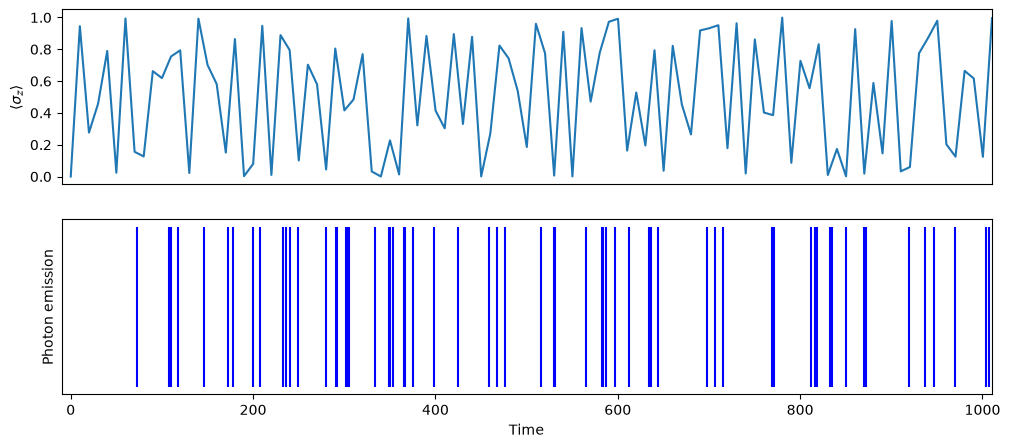

In [2]:
max_time=1000
sz = result.expect[0]

plt.figure(figsize=(12, 5))
plt.subplot(2,1,1)
plt.plot(times,sz[0])
plt.xticks([])
plt.xlim([-10,max_time+10])
plt.ylabel(r"$\langle \sigma_z \rangle$")
plt.subplot(2,1,2)
plt.xlim([-10,max_time+10])
plt.yticks([])
plt.xlabel("Time")
plt.ylabel("Photon emission")
plt.vlines(spikes, 0, 1, color='b', label="emission")
plt.show()

## Waiting time distribution

After a photon is emitted, the next one tends to be emitted at $\tau_{n}=(2n+1)\pi/\Omega$, the waiting time distribution show peaks at $\tau_{n}$.  The peak height gradually descrease due to the memory loss with decay rate $\gamma$.  The following plot clear show that.

mean waiting time  =  19.77132909595461
standard deviation =  18.347104524088426
likely poissonian


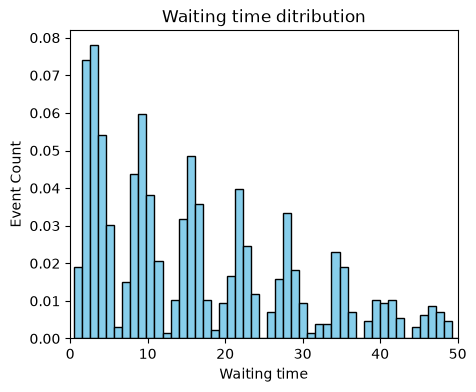

In [3]:
wtime = np.array([])
for i in range(n_spikes-1):
    wtime = np.append(wtime,spikes[i+1]-spikes[i])

mean = sum(wtime)/len(wtime)
dev = np.sqrt(sum(wtime**2)/len(wtime) - mean**2)

print("mean waiting time  = ",mean)
print("standard deviation = ",dev)

if dev < 0.9*mean:
    print("likely sub-poissonian")
elif dev > 1.1*mean:
    print("likely super-poissonian")
else:
    print("likely poissonian")

plt.figure(figsize=(5, 4))
plt.hist(wtime, density=True, bins=100, color='skyblue', edgecolor='black')
plt.title("Waiting time ditribution")
plt.xlim([0,50])
plt.xlabel("Waiting time")
plt.ylabel("Event Count")
plt.show()

## Second-order coherence

As we have seen above, the time separation between two photons is about $\tau_{n}$.  Hence, $g^{(2)}(\tau)$ should have peaks at $\tau_{n}$, corresponding to bunching.  The anti-bunching behavior at $\tau=0$ won't change even with the driving since two photons cannot be emitted at the same time.  Due to insufficient sampling, higher order peaks are hindered by statistical noises.  However, the first peak at $\tau_{1}$ is clearly visible.

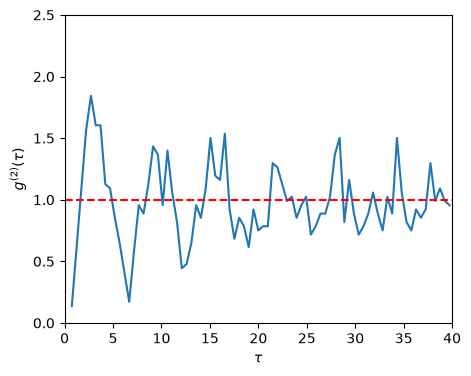

In [4]:
tau_max = 40  # max correlation time

dN = 50

def pair_times(spikes):

    time_gap = np.array([])
    i=1


    while i < n_spikes-dN:
        t0 = spikes[i]
        j = i+1
        while  (j < n_spikes) :
            t1 = spikes[j]
            if t1-t0 <= tau_max:
                time_gap = np.append(time_gap,t1-t0)
                j += 1
            else:
                break
        i += 1
    return time_gap

pair_time_gap = pair_times(spikes)

nbins = 80
dtau = tau_max/nbins
norm = (n_spikes-dN)*n_spikes /spikes[n_spikes-1] * dtau 

counts, bin = np.histogram(pair_time_gap, bins=nbins)
n=len(bin)
x = (bin[0:n-1]+bin[1:n])/2
y = counts/norm

plt.figure(figsize=(5, 4))
plt.ylim([0,2.5])
plt.plot(x,y)
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.axhline(y=1, color='r', linestyle='--')
plt.show()